In [1]:
using Gridap.ODEs
using Gridap        
using GridapGmsh
using Gridap.Geometry
using Gridap.TensorValues
using Plots
using LinearAlgebra
using  Gridap.Fields
using  Gridap.CellData
using  Gridap.ReferenceFEs  
using  Gridap.Fields
using Random
using LinearAlgebra
using Gridap.Arrays
using Base.Iterators
using LineSearches: BackTracking

In [2]:
const E = 32.1e9
const ν = 0.25
const G = E/(2*(1+ν))
const λ_ps = (E*ν)/((1+ν)*(1-2*ν)) 
const μ = G
const λ = λ_ps 
ρ = 2405
G0 = 5e8
fₜ = 4e6
r = 1.5e-3
const E_0_dot1 = 1.0e-6
const c1 = 0.055

0.055

In [3]:
Fric_ang = π/9
cϕ = cos(Fric_ang)
tϕ = tan(Fric_ang)
coh = 2e6
k1 = 1.0
k2 = 1.0
k3 = 0.0  # 1.0 for compressive shear

0.0

In [4]:
model = GmshDiscreteModel("BrazilianDiskpInclinedNotch2D.msh")
writevtk(model,"BrazilianDiskpInclinedNotch2D")

Info    : Reading 'BrazilianDiskpInclinedNotch2D.msh'...
Info    : 18 entities
Info    : 21186 nodes
Info    : 42102 elements
Info    : Done reading 'BrazilianDiskpInclinedNotch2D.msh'


3-element Vector{Vector{String}}:
 ["BrazilianDiskpInclinedNotch2D_0.vtu"]
 ["BrazilianDiskpInclinedNotch2D_1.vtu"]
 ["BrazilianDiskpInclinedNotch2D_2.vtu"]

In [5]:
order = 1
reffeG = ReferenceFE(lagrangian,VectorValue{1,Float64},order)
VG = TestFESpace(model,reffeG;
          conformity=:H1)

order = 1
reffephi  = ReferenceFE(lagrangian,Float64,order)
Vphi  = TestFESpace(model,reffephi;
          conformity=:H1)
Uphi = TrialFESpace(Vphi)
f_new = 1.0

1.0

In [6]:
order = 1
reffe = ReferenceFE(lagrangian,VectorValue{2,Float64},order)
V = TestFESpace(model,reffe;
          conformity=:H1,  dirichlet_tags=["BottomEdge","TopEdge"],
          dirichlet_masks=[(false,true),(false,true)]) 

UnconstrainedFESpace()

In [7]:
Ω = Triangulation(model)
degree = 2*order
dΩ = Measure(Ω,degree)

Measure()

In [8]:
labels = get_face_labeling(model)
LoadTagId = get_tag_from_name(labels,"BottomEdge")
Γ_Load = BoundaryTriangulation(model,tags = LoadTagId)
dΓ_Load = Measure(Γ_Load,degree)
n_Γ_Load = get_normal_vector(Γ_Load)
LoadTagId_top = get_tag_from_name(labels,"TopEdge")
Γ_Load_top = BoundaryTriangulation(model,tags = LoadTagId_top)
dΓ_Load_top = Measure(Γ_Load_top,degree)
n_Γ_Load_top = get_normal_vector(Γ_Load_top)

GenericCellField():
 num_cells: 4
 DomainStyle: ReferenceDomain()
 Triangulation: BoundaryTriangulation()
 Triangulation id: 12937728961855370880

In [9]:
Gr = get_grid(model)
nodes = get_node_coordinates(Gr)
Nₑ, Nₙ = num_cells(model), num_nodes(model)
nodeCoordX, nodeCoordY = [nodes[i][1] for i in 1:Nₙ], [nodes[i][2] for i in 1:Nₙ]
elem = get_cell_node_ids(Gr)

42094-element Table{Int32, Vector{Int32}, Vector{Int32}}:
 [7362, 9244, 21014]
 [3944, 3950, 17769]
 [413, 7358, 21012]
 [353, 16246, 21134]
 [4, 413, 20343]
 [277, 391, 20334]
 [277, 5825, 20702]
 [19398, 20382, 20554]
 [278, 5895, 9882]
 [14750, 17736, 20827]
 [414, 17736, 20827]
 [277, 5825, 20334]
 [6081, 15688, 20980]
 ⋮
 [20382, 21112, 21113]
 [20504, 20841, 20977]
 [20533, 20538, 20825]
 [20546, 20547, 20575]
 [20567, 20731, 20732]
 [20605, 20606, 20608]
 [20606, 20608, 20644]
 [20608, 20614, 20644]
 [20626, 20685, 20772]
 [20627, 20630, 20642]
 [20633, 20638, 20711]
 [20901, 20902, 20958]

In [10]:
dΩ_ro = Measure(Ω,1)
x_S = get_cell_points(dΩ_ro)

CellPoint()

In [11]:
using NearestNeighbors
data = zeros(2,Nₙ)
data[1,:] =nodeCoordX
data[2,:] =nodeCoordY
points = data
balltree = BallTree(data)
idxs = inrange(balltree, points, r, true)

21186-element Vector{Vector{Int64}}:
 [1]
 [2]
 [3]
 [4]
 [5, 6, 233, 234, 235, 236, 237, 238, 313, 321  …  6108, 20258, 20268, 20269, 20302, 20463, 20650, 20881, 20892, 20926]
 [5, 6, 234, 235, 236, 237, 238, 239, 313, 321  …  20269, 20302, 20354, 20463, 20510, 20589, 20881, 20926, 20939, 21157]
 [7, 8, 201, 202, 269, 270, 271, 272, 314, 320  …  18134, 18802, 20355, 20525, 20526, 20580, 20725, 20880, 20987, 21181]
 [7, 8, 201, 202, 203, 270, 271, 272, 314, 320  …  20355, 20522, 20526, 20601, 20665, 20725, 20880, 20987, 21181, 21182]
 [9]
 [10]
 [11]
 [12]
 [13]
 ⋮
 [190, 191, 192, 193, 194, 195, 280, 344, 420, 15676  …  16476, 16477, 16579, 17859, 20259, 20689, 20746, 21101, 21125, 21175]
 [4340, 4341, 5336, 6087, 6089, 6119, 6120, 6121, 15634, 16140  …  20750, 20752, 20753, 20754, 20792, 20811, 20868, 20927, 21137, 21176]
 [29, 30, 31, 32, 281, 351, 385, 421, 4316, 5388  …  5898, 5982, 9630, 10275, 10276, 20550, 20586, 20949, 21165, 21177]
 [125, 126, 127, 128, 282, 352, 386, 422, 16

In [12]:
function G_kill(σ_eq,σ_eq1,σ_eq2,dot_σ_eq,fₜ)
 G_kill = 0.25*G0.*((( (σ_eq1./fₜ -1)+ abs∘(σ_eq1./fₜ - 1))).+(( (σ_eq2./coh -1)+ abs∘(σ_eq2./coh - 1)))).*((dot_σ_eq)+ abs∘(dot_σ_eq))
    return G_kill
end

G_kill (generic function with 1 method)

In [13]:
function new_EnergyState(ψPlusPrev_in,t_s_in,ψhPos_in)
    ψPlus_in = ψhPos_in
    if ψPlus_in <= ψPlusPrev_in
        ψPlus_out = ψPlusPrev_in 
         tPlus_out = t_s_in
        damaged = false
    else
        ψPlus_out = ψPlus_in
        tPlus_out = T
        damaged = true
    end
    damaged, ψPlus_out, tPlus_out   
end


function new_EnergyStateAvg(ψPlusPrev_in,ψhPos_in,ψhPos_prev)
    ψPlus_in = ψhPos_in
    if ψPlus_in <= ψPlusPrev_in
        ψPlus_out = ψPlusPrev_in 
        damaged = false
    else
        ψPlus_out = 0.5*(ψPlus_in + ψhPos_prev)
        damaged = true
    end
    damaged, ψPlus_out   
end

new_EnergyStateAvg (generic function with 1 method)

In [14]:
σ(ε_nl) =  λ*tr(ε_nl)*one(ε_nl) + 2*μ*ε_nl

σ (generic function with 1 method)

In [15]:
function σ_eq(ε, ε_nl)
    εArray, εArray_nl = get_array.((ε_nl, ε_nl))
    Λ, P = eigen(εArray)
    Λ_nl, P_nl = eigen(εArray_nl)

    # Create Λpos and Λpos_nl matrices
    Λpos = diagm(0 => max.(0, Λ))
    Λpos_nl = diagm(0 => max.(0, Λ_nl))

    # Compute εPos and εPos_nl
    εPos = TensorValue(P * Λpos * P')
    εPos_nl = TensorValue(P_nl * Λpos_nl * P_nl')

    
   e1 = 0.5*(Λ_nl[1]-abs(Λ_nl[1]))
    e2 = 0.5*(Λ_nl[2]-abs(Λ_nl[2]))
    e1 = min(e1,e2)
    e2 = max(e1,e2)
    tre1e2_min = 0.5*((Λ_nl[1]+Λ_nl[2])-abs(Λ_nl[1]+Λ_nl[2]))
    
    En_neg_temp = μ*(e2-e1)/cϕ + (λ*(tre1e2_min)+μ*(e1+e2))*tϕ
    En_neg = 0.5*(En_neg_temp + abs(En_neg_temp))
    # Compute ψPos
    ψPos = (0.5 * ((tr(ε_nl) >= 0) *k1* (λ * tr(ε_nl) * tr(ε_nl)) + k2*2μ * (εPos_nl ⊙ εPos_nl))) + (0.5/G)*k3*En_neg*En_neg

    return √(2 * ψPos * E)
end


function σ_eq1(ε, ε_nl)
    εArray, εArray_nl = get_array.((ε_nl, ε_nl))
    Λ, P = eigen(εArray)
    Λ_nl, P_nl = eigen(εArray_nl)

    # Create Λpos and Λpos_nl matrices
    Λpos = diagm(0 => max.(0, Λ))
    Λpos_nl = diagm(0 => max.(0, Λ_nl))

    # Compute εPos and εPos_nl
    εPos = TensorValue(P * Λpos * P')
    εPos_nl = TensorValue(P_nl * Λpos_nl * P_nl')

    # Compute ψPos
    ψPos = (0.5 * ((tr(ε_nl) >= 0) *k1* (λ * tr(ε_nl) * tr(ε_nl)) + k2*2μ * (εPos_nl ⊙ εPos_nl))) 

    return √(2 * ψPos * E)
end

function σ_eq2(ε, ε_nl)
    εArray, εArray_nl = get_array.((ε_nl, ε_nl))
    Λ, P = eigen(εArray)
    Λ_nl, P_nl = eigen(εArray_nl)

    # Create Λpos and Λpos_nl matrices
    Λpos = diagm(0 => max.(0, Λ))
    Λpos_nl = diagm(0 => max.(0, Λ_nl))

 
    
   e1 = 0.5*(Λ_nl[1]-abs(Λ_nl[1]))
    e2 = 0.5*(Λ_nl[2]-abs(Λ_nl[2]))
    e1 = min(e1,e2)
    e2 = max(e1,e2)
    tre1e2_min = 0.5*((Λ_nl[1]+Λ_nl[2])-abs(Λ_nl[1]+Λ_nl[2]))
    
    En_neg_temp = μ*(e2-e1)/cϕ + (λ*(tre1e2_min)+μ*(e1+e2))*tϕ
    En_neg = 0.5*(En_neg_temp + abs(En_neg_temp))
    # Compute ψPos
    ψPos = (0.5/G)*k3*En_neg*En_neg

    return √(2 * ψPos * E)
end

σ_eq2 (generic function with 1 method)

In [16]:
function nonLocalGk(G_k_prev,t_k_prev)
    GkVec = evaluate(G_k_prev,x_S)
    TkVec = evaluate(t_k_prev,x_S)

    caches = [array_cache(GkVec) for k in 1:Threads.nthreads()]
    caches_T = [array_cache(TkVec) for k in 1:Threads.nthreads()]

    # Pre-allocate arrays
    Gk_nds = zeros(Nₙ)
    Tk_nds = zeros(Nₙ)
    Gk_sum = zeros(Nₙ)
   Tk_sum = zeros(Nₙ)
    Gk_count = zeros(Int, Nₙ)
    Threads.@threads for iel in 1:Nₑ
        cache = caches[Threads.threadid()]
        cache_T = caches_T[Threads.threadid()]
        ElNdInd = elem[iel]
    val_G = getindex!(cache, GkVec, iel)
    val_T = getindex!(cache_T, TkVec, iel)
for node in ElNdInd
        Gk_sum[node] += val_G[1]
        Tk_sum[node] += val_T[1]
        Gk_count[node] += 1
        end
    end
Gk_nds = Gk_sum ./ Gk_count
Tk_nds = Tk_sum ./ Gk_count
  Gk_nds_NL = zeros(Nₙ)
    Threads.@threads for nd_id in 1:Nₙ
        NeighHood = idxs[nd_id]
        @inbounds Gk_nds_NL[nd_id] = (sum(Gk_nds[NeighHood]) ) / (length(NeighHood))
    end
    return Gk_nds_NL,Tk_nds
end

nonLocalGk (generic function with 1 method)

In [17]:
function nonlocalfield(Gk_nds, t)
    ϕVec_st = similar(Gk_nds)  # Use similar to create an array with the same type and size as Gk_nds
    @. ϕVec_st = exp(-(Gk_nds * t))  # Use broadcasting to calculate the values in a vectorized way
    return FEFunction(Uphi, ϕVec_st)
end

nonlocalfield (generic function with 1 method)

In [18]:
function project(q,model,dΩ,order)
  reffe = ReferenceFE(lagrangian,Float64,order)
  V = FESpace(model,reffe,conformity=:L2)
  a(u,v) = ∫( u*v )*dΩ
  l(v) = ∫( v*q )*dΩ
  op = AffineFEOperator(a,l,V,V)
  qh = solve(op)
  qh
end

function project_vector(q,model,dΩ,order)
reffe = ReferenceFE(lagrangian,VectorValue{2,Float64},order)
V = TestFESpace(model,reffe;
          conformity=:H1)
  a(u,v) = ∫( u⋅v )*dΩ
  l(v) = ∫( v⋅q )*dΩ
  op = AffineFEOperator(a,l,V,V)
  qh = solve(op)
  qh
end

project_vector (generic function with 1 method)

In [19]:
function E_dot(ε_new,ε_old)
    εArray, εArray_nl = get_array.((ε_new,ε_old))
    Λ, P = eigen(εArray)
    Λ_nl, P_nl = eigen(εArray_nl)
    e1 = Λ[1]
    e2 = Λ[2]
    e_nl1 = Λ_nl[1]
    e_nl2 = Λ_nl[2]
     Λ_new = max(e1,e2)
     Λ_old = max(e_nl1,e_nl2)
    E_dot = (1/T)*(Λ_new-Λ_old)
end

E_dot (generic function with 1 method)

In [20]:
function RateDepGc(_E_dot)
    if _E_dot > E_0_dot1
     ft2 = fₜ*(1+((_E_dot/E_0_dot1)^c1 - 1 ))
    else 
         ft2 = fₜ
    end
    return  ft2
end

RateDepGc (generic function with 1 method)

## constant average acceleration method

In [21]:
function step_disp(uApp,dot_σ_eq,uh,vh,ah,G_k_cell,ϕ,dt,t_cell,dot_E,uh_upd,G_k_prev,trac_top,trac)
           
solver = LUSolver()  
u1(x) = VectorValue(0.0,uApp)
u2(x) = VectorValue(0.0,-uApp)
U = TrialFESpace(V,[u1,u2])
σ_eq_s = σ_eq∘((ε(uh_upd))*ϕ,(ε(uh_upd))*ϕ)
σ_eq_s_1 = σ_eq1∘((ε(uh_upd))*ϕ,(ε(uh_upd))*ϕ)
σ_eq_s_2 = σ_eq2∘((ε(uh_upd))*ϕ,(ε(uh_upd))*ϕ)
ft_new= fₜ #RateDepGc∘(dot_E) #modify it back after experimenting
G_k_in = G_kill(σ_eq_s,σ_eq_s_1,σ_eq_s_2,dot_σ_eq,ft_new)
update_state!(new_EnergyState,G_k_cell,t_cell,G_k_in)
G_k_nd_nl,t_nds = nonLocalGk(G_k_cell,t_cell)
ϕ = (nonlocalfield(G_k_nd_nl,t_nds))
    m(t, u, v) = ∫(ρ*v⋅(∂t(∂t(u))))dΩ
      a(t,u,v) = ∫( (ε(v)) ⊙ ((σ∘((ε(u))*(ϕ+(1e-4) )))*(ϕ +(1e-4))))*dΩ



res(t, u, v) = m(t, u, v) + a(t, u, v) 

ls = LUSolver()
nl_solver = NLSolver(ls, method=:newton, iterations=10, show_trace=true)

order = 2
op = TransientFEOperator(res,U,V;order)
t0 = T-dt
tF = T
γ = 0.5
β = 0.25   
ode_solver = Newmark(ls,dt,γ,β)
sol_t = solve(ode_solver,op,(uh,vh,ah),t0,tF)
u_new = zero(V)
        for (uhn,tn) in sol_t
            u_new = uhn
        end

return u_new,ϕ,G_k_cell,t_cell, G_k_nd_nl, ft_new, t_nds, cache
end

step_disp (generic function with 1 method)

In [22]:
cd("FlttenedBS")
cd("TensileShear")

In [23]:
ft_new =interpolate_everywhere(fₜ,Vphi)
G_k_cell = CellState(0.0,dΩ_ro)
T= 0.0
T0 = 1e-6
g= 0.0 #0.0 #9.8
t_cell = CellState(T,dΩ_ro)
uApp = 0.0
vApp_c = 0.05
vApp = 0.0
delT = 1e-7
Tmax = 2e-4
Load = Float64[]
Displacement = Float64[]
push!(Load, 0.0)
push!(Displacement, 0.0)
trac_top = VectorValue(0.0,-2e6)
trac = VectorValue(0.0,2e6)
count_n = 0
count_inner = 0
uh = zero(V)
dt=delT
uh_in_FE = zero(V)
 uh_iter = zero(V)
uh_iter_p = zero(V)
vh_iter_cell = CellState(VectorValue(0.0,0.0),dΩ)
ah_iter_cell = CellState(VectorValue(0.0,0.0),dΩ)
 #VectorValue(0.0,-vApp) # VectorValue(0.0,0.0)
v1(x) = VectorValue(0.0,vApp)
v2(x) = VectorValue(0.0,-vApp)
Uv = TrialFESpace(V,[v1,v2])
a2(x) =VectorValue(0.0,-g) 

Ua = TrialFESpace(V,[a2,a2])
vh_vec = get_free_dof_values(uh)
vh_iter = FEFunction(Uv,vh_vec)
vh_iter_p = vh_iter
ah_vec = get_free_dof_values(uh)
ah_iter = FEFunction(Ua,ah_vec)
ah_iter_p = ah_iter
dot_σ_eq = (σ_eq∘(ε(uh),(ε(uh))) - σ_eq∘(ε(uh_in_FE),(ε(uh_in_FE))))./delT
G_k_cell = CellState(0.0,dΩ_ro)
G_k_prev = zero(Vphi)
innerMax = 5
dot_E = E_dot∘(ε(uh),ε(uh_in_FE))
G_k_nd_nl,t_nds = nonLocalGk(G_k_cell,t_cell)
ϕ = interpolate_everywhere(f_new,Uphi)
σ_eq_s = σ_eq∘(ε(uh),(ε(uh)))
cache = nothing
while T < Tmax 
   
        T = T + delT
    vApp = vApp_c
    count_n = count_n +1
    # vApp = 17.4e-3 #g*T
#     if T < 1e-6
#         vApp = vApp_c*(T/T0)
#     end
v1(x) = VectorValue(0.0,vApp)
v2(x) = VectorValue(0.0,-vApp)
Uv = TrialFESpace(V,[v1,v2])
    uApp  = T*vApp
    uh_iter = uh

  
ah_vec = get_free_dof_values(ah_iter)
ah_vec = (4/(delT*delT))*(get_free_dof_values(uh_iter)-get_free_dof_values(uh_iter_p)-delT*get_free_dof_values(vh_iter))-ah_vec 
ah_iter = FEFunction(Ua,ah_vec)
vh_vec = get_free_dof_values(vh_iter)
vh_vec = vh_vec + 0.5*delT*(get_free_dof_values(ah_iter_p)+get_free_dof_values(ah_iter))  
vh_iter = FEFunction(Uv,vh_vec)
        dot_E = E_dot∘(ε(uh_iter),ε(uh_iter_p))
    uh_iter_p = uh_iter
    vh_iter_p = vh_iter
    ah_iter_p = ah_iter
    print("\n Entering displacemtent step :", float(uApp)) 
    for inner = 1:innerMax
   
    uh,ϕ,G_k_cell,t_cell,G_k_nd_nl,ft_new,t_nds,cache =  step_disp(uApp,dot_σ_eq,uh_iter,vh_iter,ah_iter,G_k_cell,ϕ,delT,t_cell,dot_E,uh,G_k_prev,trac_top,trac)     
    dot_σ_eq = (σ_eq∘(ε(uh)*ϕ,(ε(uh))*(ϕ+1e-6)))./T
    e = uh-uh_in_FE      
    err = sqrt(sum( ∫( e⊙e )*dΩ ))
    print("\n Error :", float(err))  
    uh_in_FE = uh
    if err <=1e-10
        break  
    end
    end
    Node_Force = sum(∫( n_Γ_Load ⋅ ((σ∘( (ε(uh))*ϕ))*ϕ )) *dΓ_Load)
    push!(Load, abs(Node_Force[2]))
    push!(Displacement, T)
    if mod(count_n,10) == 0
   writevtk(Ω,"FlattendBS_$count_n",cellfields=["disp"=>uh,"phi"=>ϕ,"sig"=>σ_eq∘((ε(uh))*ϕ,(ε(uh))*ϕ)])  
    end
end


 Entering displacemtent step :5.0e-9
 Error :2.2101128108232177e-11
 Entering displacemtent step :1.0e-8
 Error :2.2690208980066643e-11
 Entering displacemtent step :1.5e-8
 Error :2.3932322991072186e-11
 Entering displacemtent step :2.0e-8
 Error :2.579653134538573e-11
 Entering displacemtent step :2.5e-8
 Error :2.8123588370531557e-11
 Entering displacemtent step :3.0e-8
 Error :3.071996290811036e-11
 Entering displacemtent step :3.5e-8
 Error :3.342834188604622e-11
 Entering displacemtent step :4.0e-8
 Error :3.614144434497626e-11
 Entering displacemtent step :4.5e-8
 Error :3.8791469347312153e-11
 Entering displacemtent step :5.0e-8
 Error :4.1338892439344345e-11
 Entering displacemtent step :5.5e-8
 Error :4.3764980695551825e-11
 Entering displacemtent step :6.0e-8
 Error :4.606556825147921e-11
 Entering displacemtent step :6.5e-8
 Error :4.8246613905214096e-11
 Entering displacemtent step :6.999999999999999e-8
 Error :5.0320879505875723e-11
 Entering displacemtent step :7.499999

 Error :1.627491587015839e-10
 Error :0.0
 Entering displacemtent step :5.950000000000013e-7
 Error :1.6364923930865573e-10
 Error :0.0
 Entering displacemtent step :6.000000000000013e-7
 Error :1.6454421184496393e-10
 Error :0.0
 Entering displacemtent step :6.050000000000014e-7
 Error :1.6542630672565318e-10
 Error :0.0
 Entering displacemtent step :6.100000000000014e-7
 Error :1.662864078349425e-10
 Error :0.0
 Entering displacemtent step :6.150000000000014e-7
 Error :1.671167730125153e-10
 Error :0.0
 Entering displacemtent step :6.200000000000015e-7
 Error :1.6791391262771056e-10
 Error :0.0
 Entering displacemtent step :6.250000000000015e-7
 Error :1.686800235822703e-10
 Error :0.0
 Entering displacemtent step :6.300000000000016e-7
 Error :1.6942208524114303e-10
 Error :0.0
 Entering displacemtent step :6.350000000000015e-7
 Error :1.7014932890223596e-10
 Error :0.0
 Entering displacemtent step :6.400000000000016e-7
 Error :1.7087061255913544e-10
 Error :0.0
 Entering displacemte

 Error :2.1711049947651093e-10
 Error :0.0
 Entering displacemtent step :1.144999999999999e-6
 Error :2.1716853102685364e-10
 Error :0.0
 Entering displacemtent step :1.149999999999999e-6
 Error :2.1720971429654528e-10
 Error :0.0
 Entering displacemtent step :1.154999999999999e-6
 Error :2.1723128319615943e-10
 Error :0.0
 Entering displacemtent step :1.1599999999999988e-6
 Error :2.1723071459521334e-10
 Error :0.0
 Entering displacemtent step :1.1649999999999988e-6
 Error :2.1720613933954453e-10
 Error :0.0
 Entering displacemtent step :1.1699999999999988e-6
 Error :2.1715651746301027e-10
 Error :0.0
 Entering displacemtent step :1.1749999999999987e-6
 Error :2.1708161867791707e-10
 Error :0.0
 Entering displacemtent step :1.1799999999999987e-6
 Error :2.1698203617815653e-10
 Error :0.0
 Entering displacemtent step :1.1849999999999986e-6
 Error :2.1685943736671154e-10
 Error :0.0
 Entering displacemtent step :1.1899999999999986e-6
 Error :2.1671697885142954e-10
 Error :0.0
 Entering 

 Entering displacemtent step :1.6849999999999991e-6
 Error :1.7672644208240331e-10
 Error :0.0
 Entering displacemtent step :1.689999999999999e-6
 Error :1.764028725656078e-10
 Error :0.0
 Entering displacemtent step :1.6949999999999992e-6
 Error :1.760766975913047e-10
 Error :0.0
 Entering displacemtent step :1.6999999999999994e-6
 Error :1.7574448264989448e-10
 Error :0.0
 Entering displacemtent step :1.7049999999999996e-6
 Error :1.7540377690330883e-10
 Error :0.0
 Entering displacemtent step :1.7099999999999997e-6
 Error :1.7505403586521698e-10
 Error :0.0
 Entering displacemtent step :1.7149999999999997e-6
 Error :1.7469608964113444e-10
 Error :0.0
 Entering displacemtent step :1.7199999999999998e-6
 Error :1.7433087572311444e-10
 Error :0.0
 Entering displacemtent step :1.725e-6
 Error :1.7395877267347813e-10
 Error :0.0
 Entering displacemtent step :1.7300000000000002e-6
 Error :1.7357996948872026e-10
 Error :0.0
 Entering displacemtent step :1.7350000000000003e-6
 Error :1.7319

 Entering displacemtent step :2.230000000000012e-6
 Error :1.1440504738411372e-10
 Error :0.0
 Entering displacemtent step :2.2350000000000125e-6
 Error :1.139448759233648e-10
 Error :0.0
 Entering displacemtent step :2.2400000000000124e-6
 Error :1.1347980708159075e-10
 Error :0.0
 Entering displacemtent step :2.245000000000013e-6
 Error :1.1300383105361646e-10
 Error :0.0
 Entering displacemtent step :2.2500000000000128e-6
 Error :1.1250616622184166e-10
 Error :0.0
 Entering displacemtent step :2.2550000000000127e-6
 Error :1.120043072437194e-10
 Error :0.0
 Entering displacemtent step :2.260000000000013e-6
 Error :1.1152935522872678e-10
 Error :0.0
 Entering displacemtent step :2.265000000000013e-6
 Error :1.1109418899721316e-10
 Error :0.0
 Entering displacemtent step :2.2700000000000134e-6
 Error :1.1070838194699177e-10
 Error :0.0
 Entering displacemtent step :2.2750000000000134e-6
 Error :1.1037210783440872e-10
 Error :0.0
 Entering displacemtent step :2.2800000000000133e-6
 Err

...

 Entering displacemtent step :7.495000000000141e-6
 Error :1.7529559837166362e-9
 Error :0.0
 Entering displacemtent step :7.500000000000141e-6
 Error :1.7524622878656503e-9
 Error :0.0
 Entering displacemtent step :7.505000000000141e-6
 Error :1.7522922902734237e-9
 Error :0.0
 Entering displacemtent step :7.510000000000141e-6
 Error :1.7522574642355363e-9
 Error :0.0
 Entering displacemtent step :7.515000000000141e-6
 Error :1.7522945075083603e-9
 Error :5.886857933999546e-12
 Entering displacemtent step :7.5200000000001415e-6
 Error :1.7525771524017312e-9
 Error :0.0
 Entering displacemtent step :7.525000000000141e-6
 Error :1.7528952812085186e-9
 Error :0.0
 Entering displacemtent step :7.530000000000141e-6
 Error :1.752870161816975e-9
 Error :3.9333916265655574e-12
 Entering displacemtent step :7.535000000000141e-6
 Error :1.7526497159355452e-9
 Error :0.0
 Entering displacemtent step :7.540000000000141e-6
 Error :1.7523326978483844e-9
 Error :3.952418058539492e-12
 Entering displ

 Entering displacemtent step :7.990000000000152e-6
 Error :1.9038907052182403e-9
 Error :0.0
 Entering displacemtent step :7.995000000000153e-6
 Error :1.9048263107436786e-9
 Error :0.0
 Entering displacemtent step :8.000000000000152e-6
 Error :1.905707572233047e-9
 Error :5.067703239150861e-12
 Entering displacemtent step :8.005000000000153e-6
 Error :1.9067547687237726e-9
 Error :0.0
 Entering displacemtent step :8.010000000000154e-6
 Error :1.907933144621784e-9
 Error :4.721993771826414e-12
 Entering displacemtent step :8.015000000000153e-6
 Error :1.909400706152711e-9
 Error :0.0
 Entering displacemtent step :8.020000000000154e-6
 Error :1.9104700671612936e-9
 Error :0.0
 Entering displacemtent step :8.025000000000153e-6
 Error :1.910923190503243e-9
 Error :0.0
 Entering displacemtent step :8.030000000000154e-6
 Error :1.910955861752606e-9
 Error :6.067728528367895e-12
 Entering displacemtent step :8.035000000000154e-6
 Error :1.9111295352453863e-9
 Error :3.4681379615720106e-12
 E

 Error :2.0169512270871704e-9
 Error :0.0
 Entering displacemtent step :8.530000000000166e-6
 Error :2.01865824176932e-9
 Error :0.0
 Entering displacemtent step :8.535000000000166e-6
 Error :2.0203349458798735e-9
 Error :0.0
 Entering displacemtent step :8.540000000000166e-6
 Error :2.022226746734599e-9
 Error :0.0
 Entering displacemtent step :8.545000000000166e-6
 Error :2.024440589983753e-9
 Error :0.0
 Entering displacemtent step :8.550000000000165e-6
 Error :2.0266673561826146e-9
 Error :0.0
 Entering displacemtent step :8.555000000000166e-6
 Error :2.0286711994350933e-9
 Error :0.0
 Entering displacemtent step :8.560000000000167e-6
 Error :2.0302852739533714e-9
 Error :0.0
 Entering displacemtent step :8.565000000000166e-6
 Error :2.0318049040027103e-9
 Error :0.0
 Entering displacemtent step :8.570000000000167e-6
 Error :2.0334020147786246e-9
 Error :0.0
 Entering displacemtent step :8.575000000000166e-6
 Error :2.03499825546916e-9
 Error :0.0
 Entering displacemtent step :8.58

 Error :2.132194723755056e-9
 Error :0.0
 Entering displacemtent step :9.075000000000178e-6
 Error :2.1320906306723456e-9
 Error :0.0
 Entering displacemtent step :9.080000000000179e-6
 Error :2.131799557079342e-9
 Error :0.0
 Entering displacemtent step :9.08500000000018e-6
 Error :2.13120830275856e-9
 Error :0.0
 Entering displacemtent step :9.090000000000179e-6
 Error :2.130675393402101e-9
 Error :3.9925834180580635e-12
 Entering displacemtent step :9.09500000000018e-6
 Error :2.1307121806077595e-9
 Error :0.0
 Entering displacemtent step :9.100000000000179e-6
 Error :2.13121089799283e-9
 Error :0.0
 Entering displacemtent step :9.10500000000018e-6
 Error :2.1316875039074926e-9
 Error :4.166244572567724e-12
 Entering displacemtent step :9.11000000000018e-6
 Error :2.132214789950329e-9
 Error :0.0
 Entering displacemtent step :9.11500000000018e-6
 Error :2.133210762667133e-9
 Error :3.3560450490169782e-12
 Entering displacemtent step :9.12000000000018e-6
 Error :2.1346008962112745e-9

 Entering displacemtent step :9.600000000000193e-6
 Error :2.1176909288676304e-9
 Error :0.0
 Entering displacemtent step :9.605000000000192e-6
 Error :2.117343833493084e-9
 Error :3.5367450561401966e-12
 Entering displacemtent step :9.610000000000193e-6
 Error :2.117087878417386e-9
 Error :0.0
 Entering displacemtent step :9.615000000000192e-6
 Error :2.1171503106536416e-9
 Error :5.303765694604805e-12
 Entering displacemtent step :9.620000000000192e-6
 Error :2.117458221617214e-9
 Error :0.0
 Entering displacemtent step :9.625000000000193e-6
 Error :2.1174567418793074e-9
 Error :0.0
 Entering displacemtent step :9.630000000000192e-6
 Error :2.1173146524233636e-9
 Error :0.0
 Entering displacemtent step :9.635000000000193e-6
 Error :2.117423366189455e-9
 Error :0.0
 Entering displacemtent step :9.640000000000192e-6
 Error :2.1176808569416777e-9
 Error :3.815096595103612e-12
 Entering displacemtent step :9.645000000000193e-6
 Error :2.1178254719041265e-9
 Error :4.9865666138080814e-12


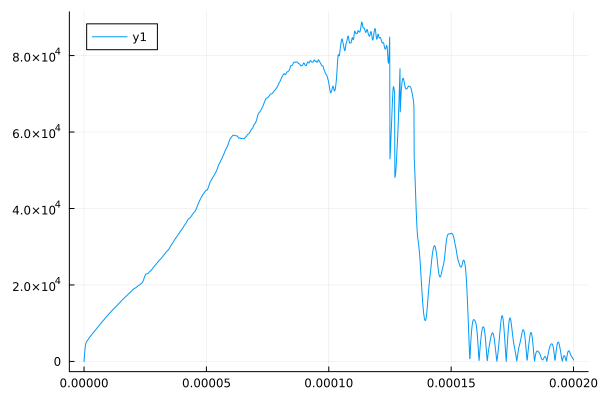

In [24]:
plot(Displacement,Load,legend=:topleft)

In [25]:
using DelimitedFiles
writedlm("DH_17p4_rhodtt.csv",  [Displacement Load], ',') 

In [ ]:
0.04-0.0375

In [ ]:
writevtk(Ω,"results_NonLocal_$count_n",cellfields=["disp"=>uh,"phi"=>ϕ,"sig"=>σ_eq∘(ε(uh),(ε(uh))*ϕ)])   

In [ ]:
Node_Force = sum(∫( n_Γ_Load ⋅ (σ∘( (ε(uh))*ϕ) )) *dΓ_Load)

In [ ]:
using DelimitedFiles
writedlm("PDeltav17p4.csv",  [Displacement Load], ',') 

In [ ]:
writevtk(Ω,"results_NonLocal_$count_n",cellfields=["disp"=>uh,"phi"=>ϕ,"sig"=>σ_eq∘(ε(uh),(ε(uh))*ϕ),"ft"=>ft_new,"Edot"=>dot_E])   

In [ ]:
writevtk(Ω,"results_NonLocal_$count_n",cellfields=["disp"=>uh,"phi"=>ϕ,"sig"=>σ_eq∘(ε(uh),(ε(uh))*ϕ)]) 

In [ ]:
8.8-8.11